# P00 - Stats log-mel basicas

Primer pipeline acustico defendible. Resume cada audio con estadisticas de log-mel por banda, duracion, RMS y zero-crossing rate. Es barato, tabular y sirve como baseline diverso para ensambles.

Esta variante corresponde a la familia que produjo el salto de priors a audio real: private LB `0.32714`, y luego `0.37607` con LogisticRegression regularizada `C=0.01`.

La idea de este notebook no es entrenar, sino mirar si el artefacto P00 esta sano y entender visualmente que informacion esta guardando.


## Imports y configuracion


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

ROOT = Path.cwd()
if ROOT.name == '02_preprocesamiento':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / '02_preprocesamiento' / 'results'
FIG_DIR = RESULTS_DIR / 'figures'
INVESTIGATION = ROOT / 'investigation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(INVESTIGATION))

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
plt.style.use('default')
plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from scripts.fat2019.data import split_labels
from scripts.fat2019.features import read_wav_mono, log_mel_spectrogram, extract_log_mel_stats

print(f'ROOT={ROOT}')
print(f'FIG_DIR={FIG_DIR.relative_to(ROOT)}')


ROOT=/home/santig14/fing/taa/2_TallerAA
FIG_DIR=02_preprocesamiento/results/figures


## 1. Inspeccion del cache

P00 usa caches tabulares. El chequeo basico es: cuantas filas tiene cada split, cuantas features produce y si aparecen `NaN`. Ademas se grafica el tamano relativo de cada cache para ver que esta variante es liviana frente a los caches de imagen.


,cache,path,rows,features,dtype,nan_count,size_mb
0,curated_basic_all,data/curated_logmel_stats_all.npz,4964,323,float32,0,5.56
1,curated_basic_500,data/curated_logmel_stats_500.npz,500,323,float32,0,0.56
2,test_basic,data/test_logmel_stats.npz,3361,323,float32,0,3.75


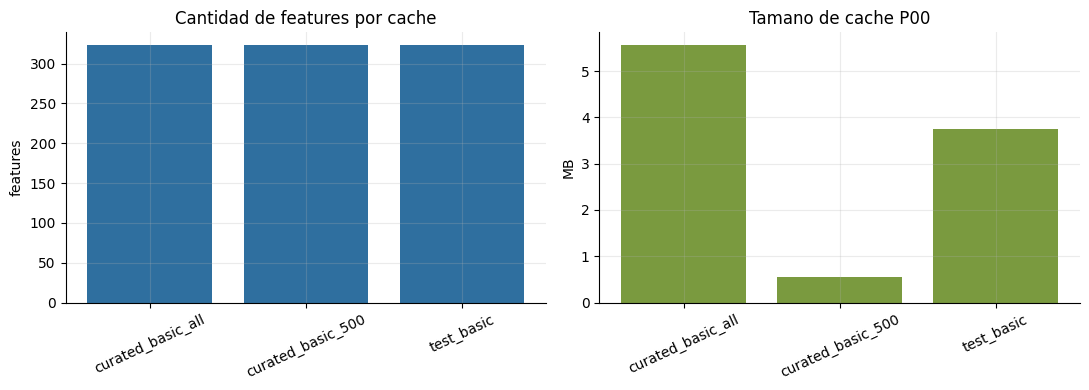

In [2]:
cache_paths = {
    'curated_basic_all': DATA_DIR / 'curated_logmel_stats_all.npz',
    'curated_basic_500': DATA_DIR / 'curated_logmel_stats_500.npz',
    'test_basic': DATA_DIR / 'test_logmel_stats.npz',
}

rows = []
for name, cache_path in cache_paths.items():
    with np.load(cache_path, allow_pickle=True) as data:
        x = data['x']
        rows.append({
            'cache': name,
            'path': str(cache_path.relative_to(ROOT)),
            'rows': x.shape[0],
            'features': x.shape[1],
            'dtype': str(x.dtype),
            'nan_count': int(np.isnan(x).sum()),
            'size_mb': round(cache_path.stat().st_size / 1024**2, 2),
        })
cache_summary = pd.DataFrame(rows)
display(cache_summary)
cache_summary.to_csv(RESULTS_DIR / 'P00_logmel_stats_basic_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(cache_summary['cache'], cache_summary['features'], color='#2f6f9f')
axes[0].set_title('Cantidad de features por cache')
axes[0].set_ylabel('features')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(cache_summary['cache'], cache_summary['size_mb'], color='#7a9a3f')
axes[1].set_title('Tamano de cache P00')
axes[1].set_ylabel('MB')
axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P00_cache_summary.png', dpi=140, bbox_inches='tight')
plt.show()


## 2. Anatomia de las 323 features

Las primeras 320 features son cuatro bloques por banda mel: media, desviacion, maximo y percentil 75. Las tres ultimas son variables globales del waveform: duracion, RMS y zero-crossing rate.


,block,features,mean,std,min,max
0,mel_mean,80,-8.1539,2.0582,-13.6960,-1.7800
1,mel_std,80,1.3191,0.7093,0.0861,4.7510
2,mel_max,80,-4.7288,1.9308,-13.3704,0.1225
3,mel_p75,80,-7.3321,2.2684,-13.8155,-0.8475
4,duration,1,7.4436,7.4891,0.3064,30.0000
5,rms,1,0.0665,0.0728,0.0005,0.8670
6,zcr,1,0.0998,0.0907,0.0004,0.5433


/tmp/ipykernel_29410/1676032283.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=['mean', 'std', 'max', 'p75'], showfliers=False)


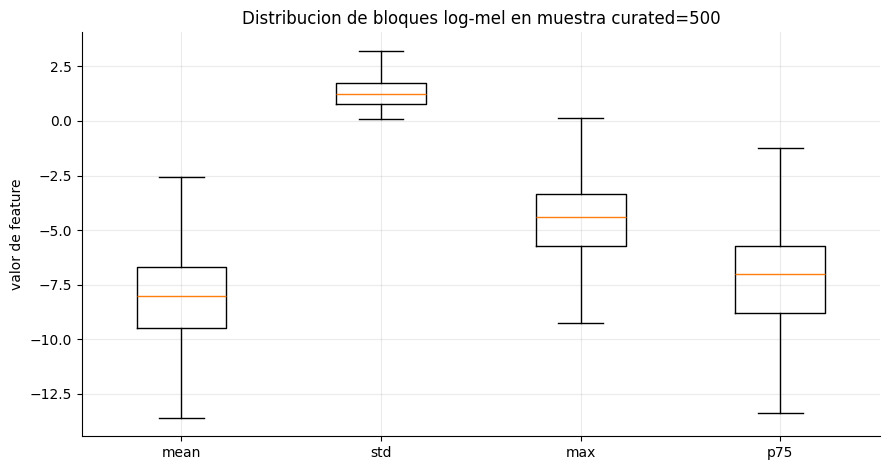

In [3]:
with np.load(DATA_DIR / 'curated_logmel_stats_500.npz', allow_pickle=True) as data:
    x500 = data['x'].astype(np.float32)
    fnames500 = data['fnames']

blocks = {
    'mel_mean': x500[:, 0:80],
    'mel_std': x500[:, 80:160],
    'mel_max': x500[:, 160:240],
    'mel_p75': x500[:, 240:320],
    'duration': x500[:, 320:321],
    'rms': x500[:, 321:322],
    'zcr': x500[:, 322:323],
}

block_summary = pd.DataFrame([
    {
        'block': name,
        'features': arr.shape[1],
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr)),
        'min': float(np.min(arr)),
        'max': float(np.max(arr)),
    }
    for name, arr in blocks.items()
])
display(block_summary.round(4))
block_summary.to_csv(RESULTS_DIR / 'P00_feature_block_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
box_data = [blocks[name].ravel() for name in ['mel_mean', 'mel_std', 'mel_max', 'mel_p75']]
ax.boxplot(box_data, labels=['mean', 'std', 'max', 'p75'], showfliers=False)
ax.set_title('Distribucion de bloques log-mel en muestra curated=500')
ax.set_ylabel('valor de feature')
fig.tight_layout()
fig.savefig(FIG_DIR / 'P00_logmel_block_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Perfil promedio por banda mel

Esta grafica conserva la lectura acustica del baseline: cada curva resume como cambia la energia por bandas de frecuencia. Aunque P00 pierde el orden temporal, todavia captura diferencias espectrales globales entre audios.


,mel_band,mean_of_mel_mean,mean_of_mel_std,mean_of_mel_max,mean_of_mel_p75
0,0,-7.7072,1.1026,-5.1248,-7.0013
1,1,-7.5526,1.1780,-4.7630,-6.7875
2,2,-7.8490,1.1843,-4.9611,-7.0742
3,3,-7.8241,1.1922,-4.8876,-7.0409
4,4,-7.8311,1.2303,-4.8144,-7.0220
5,5,-7.8482,1.2680,-4.7467,-7.0163
6,6,-7.8564,1.2992,-4.6765,-6.9943
7,7,-7.8702,1.3296,-4.6173,-6.9862
8,8,-7.9030,1.3481,-4.5807,-7.0085
9,9,-7.9389,1.3592,-4.5670,-7.0456


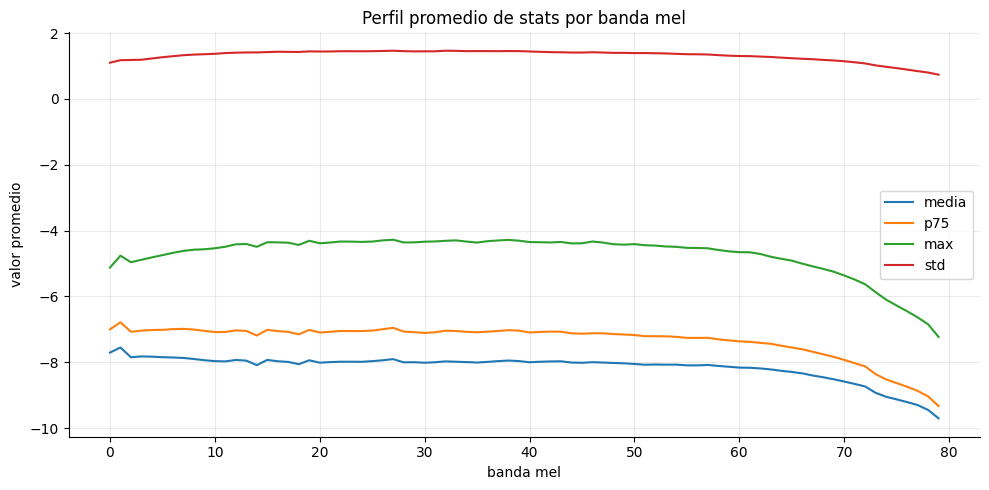

In [4]:
mel_band = np.arange(80)
profiles = pd.DataFrame({
    'mel_band': mel_band,
    'mean_of_mel_mean': blocks['mel_mean'].mean(axis=0),
    'mean_of_mel_std': blocks['mel_std'].mean(axis=0),
    'mean_of_mel_max': blocks['mel_max'].mean(axis=0),
    'mean_of_mel_p75': blocks['mel_p75'].mean(axis=0),
})
display(profiles.head(10).round(4))
profiles.to_csv(RESULTS_DIR / 'P00_mel_band_profiles.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mel_band, profiles['mean_of_mel_mean'], label='media')
ax.plot(mel_band, profiles['mean_of_mel_p75'], label='p75')
ax.plot(mel_band, profiles['mean_of_mel_max'], label='max')
ax.plot(mel_band, profiles['mean_of_mel_std'], label='std')
ax.set_title('Perfil promedio de stats por banda mel')
ax.set_xlabel('banda mel')
ax.set_ylabel('valor promedio')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'P00_mel_band_profiles.png', dpi=140, bbox_inches='tight')
plt.show()


## 4. Variables globales del waveform

P00 no solo usa energia por bandas. Tambien agrega duracion, RMS y zero-crossing rate. Estas features pueden separar sonidos largos/cortos, clips silenciosos/energeticos y texturas con mucha oscilacion.


,duration_seconds,rms,zero_crossing_rate
count,4964.0000,4964.0000,4964.0000
mean,7.6373,0.0659,0.1026
std,7.6660,0.0710,0.0945
min,0.3000,0.0001,0.0002
5%,0.4969,0.0039,0.0105
25%,1.6110,0.0183,0.0385
50%,4.6759,0.0441,0.0734
75%,11.1456,0.0908,0.1348
95%,24.4943,0.1954,0.2994
max,30.0000,0.8670,0.7566


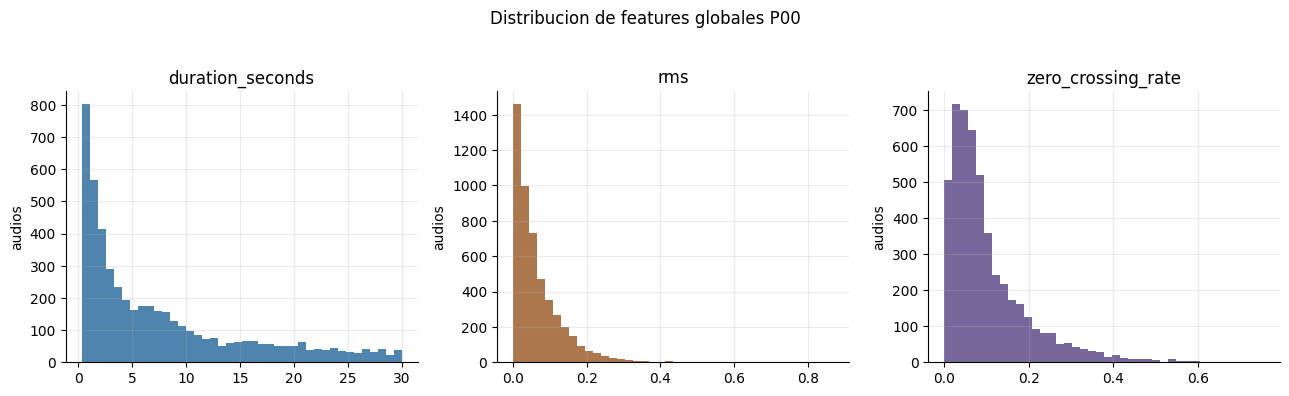

In [5]:
with np.load(DATA_DIR / 'curated_logmel_stats_all.npz', allow_pickle=True) as data:
    x_all = data['x'].astype(np.float32)

global_features = pd.DataFrame({
    'duration_seconds': x_all[:, 320],
    'rms': x_all[:, 321],
    'zero_crossing_rate': x_all[:, 322],
})
display(global_features.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(4))
global_features.to_csv(RESULTS_DIR / 'P00_global_waveform_features.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, color in zip(axes, global_features.columns, ['#2f6f9f', '#9f5f2f', '#5f4b8b']):
    ax.hist(global_features[col], bins=40, color=color, alpha=0.85)
    ax.set_title(col)
    ax.set_ylabel('audios')
fig.suptitle('Distribucion de features globales P00', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P00_global_feature_histograms.png', dpi=140, bbox_inches='tight')
plt.show()


## 5. Verificacion en un audio concreto

Para cerrar el chequeo, se toma un WAV real, se calcula su log-mel y se muestra el espectrograma. Esta grafica explica por que P00 es un resumen: sus 323 features salen de comprimir una matriz tiempo-frecuencia mucho mas rica.


,fname,labels,sample_rate,duration_seconds,logmel_shape,stats_features
0,0006ae4e.wav,Bark,44100,7.04,"(80, 605)",323


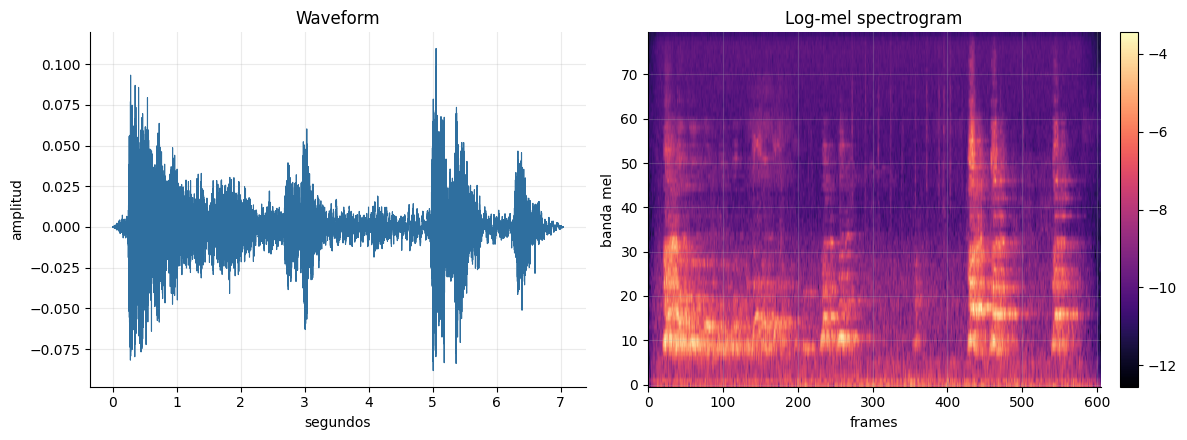

In [6]:
curated = pd.read_csv(DATA_DIR / 'train_curated.csv')
row = curated.iloc[0]
sample_rate, waveform = read_wav_mono(str(DATA_DIR / row['fname']))
logmel = log_mel_spectrogram(
    waveform,
    sample_rate=sample_rate,
    n_fft=1024,
    hop_length=512,
    n_mels=80,
    fmin=20.0,
    fmax=sample_rate / 2,
)
stats = extract_log_mel_stats(waveform, sample_rate=sample_rate, fmax=sample_rate / 2)

display(pd.DataFrame([{
    'fname': row['fname'],
    'labels': row['labels'],
    'sample_rate': sample_rate,
    'duration_seconds': round(waveform.size / sample_rate, 3),
    'logmel_shape': str(logmel.shape),
    'stats_features': stats.shape[0],
}]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(np.arange(waveform.size) / sample_rate, waveform, linewidth=0.8, color='#2f6f9f')
axes[0].set_title('Waveform')
axes[0].set_xlabel('segundos')
axes[0].set_ylabel('amplitud')

im = axes[1].imshow(logmel, origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('Log-mel spectrogram')
axes[1].set_xlabel('frames')
axes[1].set_ylabel('banda mel')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P00_single_audio_waveform_logmel.png', dpi=140, bbox_inches='tight')
plt.show()


## 6. Experimentos que justifican `C=0.01`

P00 no termina en un modelo cualquiera: estas features se probaron con LogisticRegression One-vs-Rest y distintas regularizaciones. La comparacion fresca esta en `03_entrenamiento/training_results.csv`, y la evidencia historica de Kaggle esta resumida en `03_entrenamiento/decision_matrix.csv` y `docs/impact_analysis/impact_drivers.md`.

La lectura es: `C=0.01` fue el mejor punto de esta familia. `C=0.02` quedo casi empatado localmente, pero no aporta mejora clara; `C=0.03` baja mas. Por eso P00 queda asociado a `logreg_c001` como baseline tabular fuerte.


,run,config,valid_lwlrap,decision,notes
0,logreg_c001,LogisticRegression OneVsRest C=0.01 basic log-...,0.576401,keep,Fresh run seed42; best sklearn among C=0.01/0....
1,logreg_c002,LogisticRegression OneVsRest C=0.02 basic log-...,0.576353,discard,Almost tied locally but historical Kaggle was ...
2,logreg_c003,LogisticRegression OneVsRest C=0.03 basic log-...,0.570624,discard,Below C=0.01


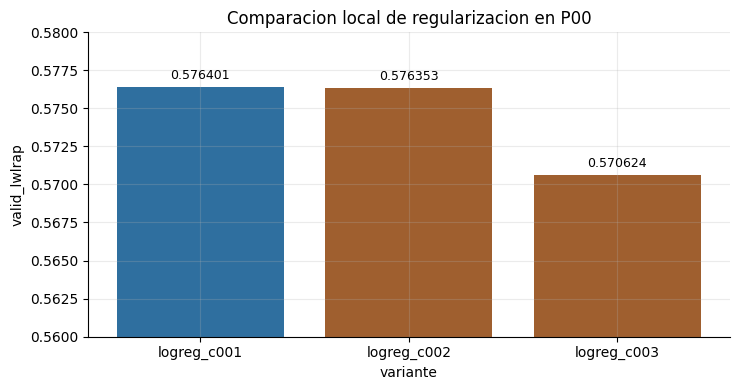

,source,evidence
0,decision_matrix.csv,sklearn_logmel_c001: Private LB 0.37607; decis...
1,docs/impact_analysis/impact_drivers.md,regularizacion C=0.01 mejora 0.32714 -> 0.37607


In [7]:
training_results = pd.read_csv(ROOT / '03_entrenamiento' / 'training_results.csv')
logreg_results = training_results[training_results['run'].str.startswith('logreg_c')].copy()
logreg_results['valid_lwlrap'] = pd.to_numeric(logreg_results['valid_lwlrap'], errors='coerce')
logreg_results = logreg_results.sort_values('valid_lwlrap', ascending=False)

display(logreg_results[['run', 'config', 'valid_lwlrap', 'decision', 'notes']])

fig, ax = plt.subplots(figsize=(7.5, 4))
colors = ['#2f6f9f' if decision == 'keep' else '#9f5f2f' for decision in logreg_results['decision']]
ax.bar(logreg_results['run'], logreg_results['valid_lwlrap'], color=colors)
ax.set_title('Comparacion local de regularizacion en P00')
ax.set_xlabel('variante')
ax.set_ylabel('valid_lwlrap')
ax.set_ylim(0.56, 0.58)
for idx, row in enumerate(logreg_results.itertuples(index=False)):
    ax.text(idx, row.valid_lwlrap + 0.0005, f'{row.valid_lwlrap:.6f}', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'P00_logreg_c_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

historical_evidence = pd.DataFrame([
    {'source': 'decision_matrix.csv', 'evidence': 'sklearn_logmel_c001: Private LB 0.37607; decision keep'},
    {'source': 'docs/impact_analysis/impact_drivers.md', 'evidence': 'regularizacion C=0.01 mejora 0.32714 -> 0.37607'},
])
display(historical_evidence)


## Decision

- Mantener P00 como baseline tabular y rama diversa.
- Usar `C=0.01` como punto regularizado fuerte en entrenamiento.
- No esperar que P00 supere a CNN: colapsa el eje temporal del espectrograma.
- Conservarlo en la historia del proyecto porque fue el primer salto acustico real y porque aporto diversidad en blends.
